# 03  -  FF2: Wachstums-Hotspots (Growth Hotspots)

**Forschungsfrage:** Welche Zählstellen zeigen den stärksten Wachstumstrend (2020-2025)? Bei Fortschreibung des aktuellen Trends: Welche Stationen werden ihr Aufkommen innerhalb von 5 Jahren verdoppeln?

**Logik (CPA Step 5):**
- **Ergebnis A:** Starkes Wachstum konzentriert sich auf bestimmte Korridore → Präventive Kapazitätserweiterung einplanen
- **Ergebnis B:** Wachstum ist stadtweit gleichmässig → Netzweite Standards anheben statt Einzelstandorte priorisieren

**Methodik:**
1. Nur konsistente Stationen verwenden (≥60% Abdeckung über alle Jahre)
2. Jahrestotale pro Station berechnen
3. Partielle Jahre (v.a. 2025) behandeln
4. Wachstumsraten, lineare Regression und CAGR pro Station
5. Trendextrapolation: Welche Stationen verdoppeln sich in 5 Jahren?

**Datengrundlage:** `velo_15min_clean.parquet` und `station_metadata.csv` aus Notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded.")


Libraries loaded.


---
## Schritt 1: Bereinigte Daten laden

Wir laden die in Notebook 02 erstellten Dateien:
- **`velo_15min_clean.parquet`**  -  15-Minuten-Velozähldaten, bereits bereinigt (Sensor-Ausfälle markiert, negative Werte korrigiert, `velo_total` berechnet)
- **`station_metadata.csv`**  -  Stationsinformationen inkl. `is_consistent`-Flag (= Station liefert über alle Jahre hinweg ≥60% Datenabdeckung)

Das Parquet-Format ist ideal für grosse DataFrames: schneller als CSV, komprimiert, behält Datentypen bei.

In [2]:
# Velodaten laden
df = pd.read_parquet("data/clean/velo_15min_clean.parquet")
meta = pd.read_csv("data/clean/station_metadata.csv")

print(f"Velo-Daten: {len(df):,} Zeilen, {df['station_id'].nunique()} Stationen")
print(f"Zeitraum:   {df['datetime'].min()} bis {df['datetime'].max()}")
print(f"Jahre:      {sorted(df['year'].unique())}")
print(f"\nStation-Metadaten: {len(meta)} Stationen")
print(f"Spalten Velo:  {list(df.columns)}")
print(f"Spalten Meta:  {list(meta.columns)}")

Velo-Daten: 4,499,163 Zeilen, 46 Stationen
Zeitraum:   2020-01-01 00:00:00 bis 2025-12-31 23:45:00
Jahre:      [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Station-Metadaten: 46 Stationen
Spalten Velo:  ['station_id', 'datetime', 'velo_in', 'velo_out', 'velo_total', 'easting', 'northing', 'year', 'month', 'hour', 'weekday', 'is_bidirectional', 'is_consistent', 'sensor_failure']
Spalten Meta:  ['station_id', 'easting', 'northing', 'is_bidirectional', 'is_consistent', 'first_date', 'last_date', 'total_valid_rows']


---
## Schritt 2: Auf konsistente Stationen filtern

**Warum dieser Schritt kritisch ist:**
Für eine faire Wachstumsanalyse brauchen wir Stationen, die über den gesamten Zeitraum 2020-2025 zuverlässig Daten liefern. Würden wir Stationen einschliessen, die erst 2023 installiert wurden, würden diese fälschlich als "extremes Wachstum" erscheinen (0 → hoch). Umgekehrt: Stationen, die 2022 abgeschaltet wurden, würden als "starker Rückgang" interpretiert.

Das `is_consistent`-Flag aus Notebook 02 markiert Stationen mit ≥60% Datenabdeckung in **jedem** Jahr. Nur diese verwenden wir.

In [3]:
n_total = df["station_id"].nunique()
df_cons = df[df["is_consistent"] == True].copy()
n_consistent = df_cons["station_id"].nunique()

print(f"Total Stationen:       {n_total}")
print(f"Konsistente Stationen: {n_consistent}")
print(f"Ausgeschlossen:        {n_total - n_consistent} ({(n_total - n_consistent) / n_total * 100:.1f}%)")
print(f"Verbleibende Zeilen:   {len(df_cons):,} ({len(df_cons) / len(df) * 100:.1f}% der Daten)")

# Zeige die konsistenten Stationen
consistent_ids = sorted(df_cons["station_id"].unique())
print(f"\nKonsistente Station-IDs: {consistent_ids}")

Total Stationen:       46
Konsistente Stationen: 12
Ausgeschlossen:        34 (73.9%)
Verbleibende Zeilen:   2,190,029 (48.7% der Daten)

Konsistente Station-IDs: [np.int64(732), np.int64(1037), np.int64(2986), np.int64(2989), np.int64(2991), np.int64(2993), np.int64(2997), np.int64(3003), np.int64(3012), np.int64(4241), np.int64(4242), np.int64(4249)]


---
## Schritt 3: Sensor-Ausfälle ausschliessen

In Notebook 02 wurden zusammenhängende Null-Serien > 6 Stunden als `is_sensor_failure = True` markiert. Diese Zeilen enthalten keine echten Zähldaten  -  sie würden die Jahressummen nach unten verzerren und künstliche "Einbrüche" erzeugen.

Wir entfernen diese Zeilen **vor** der Aggregation zu Jahrestotalen.

In [4]:
# Sensor-Ausfälle entfernen (falls Spalte vorhanden)
if "is_sensor_failure" in df_cons.columns:
    n_before = len(df_cons)
    n_failures = df_cons["is_sensor_failure"].sum()
    df_cons = df_cons[df_cons["is_sensor_failure"] == False].copy()
    print(f"Sensor-Ausfälle entfernt: {n_failures:,} Zeilen ({n_failures / n_before * 100:.2f}%)")
    print(f"Verbleibend: {len(df_cons):,} Zeilen")
else:
    print("Spalte 'is_sensor_failure' nicht vorhanden  -  vermutlich bereits in NB02 gefiltert.")
    print("Prüfe NaN-Werte in velo_total als Alternative:")
    n_null = df_cons["velo_total"].isnull().sum()
    print(f"  NaN in velo_total: {n_null:,} ({n_null / len(df_cons) * 100:.2f}%)")
    # NaN-Zeilen entfernen  -  diese können nicht zu Jahressummen beitragen
    df_cons = df_cons.dropna(subset=["velo_total"]).copy()
    print(f"  Nach NaN-Entfernung: {len(df_cons):,} Zeilen")

Spalte 'is_sensor_failure' nicht vorhanden  -  vermutlich bereits in NB02 gefiltert.
Prüfe NaN-Werte in velo_total als Alternative:
  NaN in velo_total: 1,690 (0.08%)
  Nach NaN-Entfernung: 2,188,339 Zeilen


---
## Schritt 4: Datenabdeckung pro Station und Jahr prüfen

Bevor wir Jahrestotale berechnen, müssen wir wissen, wie vollständig die Daten pro Station-Jahr-Kombination sind. Ein Jahr mit nur 3 Monaten Daten darf nicht direkt mit einem Volljahr verglichen werden.

**Erwartete Intervalle pro Jahr:** 365.25 × 24 × 4 ≈ 35'064 (15-Min-Intervalle)

Wir berechnen für jede Station-Jahr-Kombination:
- Anzahl tatsächlicher Messungen
- Abdeckungsrate (coverage)
- Erster und letzter Messpunkt

In [5]:
INTERVALS_PER_YEAR = 365.25 * 24 * 4  # ~35'064

coverage = df_cons.groupby(["station_id", "year"]).agg(
    n_records=("velo_total", "count"),
    first_date=("datetime", "min"),
    last_date=("datetime", "max"),
).reset_index()

coverage["coverage_pct"] = (coverage["n_records"] / INTERVALS_PER_YEAR * 100).round(1)

# Pivot: Stationen als Zeilen, Jahre als Spalten
coverage_pivot = coverage.pivot(index="station_id", columns="year", values="coverage_pct")
print("Datenabdeckung (%) pro Station und Jahr:\n")
print(coverage_pivot.to_string())

# Zusammenfassung
print(f"\nDurchschnittliche Abdeckung pro Jahr:")
print(coverage.groupby("year")["coverage_pct"].agg(["mean", "min", "max"]).round(1))

Datenabdeckung (%) pro Station und Jahr:

year        2020  2021  2022  2023   2024  2025
station_id                                     
732         99.9  99.9  99.9  99.9  100.2  99.6
1037        99.6  99.9  99.9  99.9  100.2  99.6
2986        99.7  98.7  99.8  99.8   89.9  40.2
2989        99.6  99.9  99.9  99.9  100.2  99.6
2991        99.3  62.3  99.9  99.9  100.2  63.5
2993        93.9  87.6  98.3  98.3  100.2  86.7
2997        59.9  99.7  99.9  99.8  100.2  99.6
3003        45.7  99.6  99.9  99.9  100.2  92.3
3012         NaN  84.3  99.9  99.9  100.2  99.6
4241         NaN  31.2  99.9  99.9  100.2  99.6
4242         NaN  31.2  99.9  99.9  100.2  99.1
4249         NaN   NaN  82.9  99.9  100.2  99.6

Durchschnittliche Abdeckung pro Jahr:
      mean   min    max
year                   
2020  87.2  45.7   99.9
2021  81.3  31.2   99.9
2022  98.3  82.9   99.9
2023  99.8  98.3   99.9
2024  99.3  89.9  100.2
2025  89.9  40.2   99.6


---
## Schritt 5: Partielle Jahre behandeln (insb. 2025)

**Problem:** 2025 ist wahrscheinlich noch nicht vollständig (die Daten enden irgendwann Mitte des Jahres). Ein Jahrestotal von z.B. 500'000 für Jan-März 2025 wäre nicht vergleichbar mit 2'000'000 für das Gesamtjahr 2024.

**Strategie:** Wir verwenden zwei Ansätze:
1. **Annualisierung**  -  Hochrechnung auf 12 Monate basierend auf der tatsächlichen Abdeckung: `annualized = raw_total / coverage × 100`
2. **Ausschluss**  -  Jahre mit <50% Abdeckung komplett ausschliessen (konservativer Ansatz)

Wir berechnen beide und verwenden primär die Annualisierung  -  mit einem Mindest-Coverage-Schwellenwert von 25%, unter dem die Hochrechnung zu unsicher wird.

In [6]:
MIN_COVERAGE_PCT = 25  # Unter 25% Abdeckung wird nicht annualisiert

# Jahrestotale berechnen (Rohsumme)
yearly_raw = df_cons.groupby(["station_id", "year"]).agg(
    velo_total_sum=("velo_total", "sum"),
    n_records=("velo_total", "count"),
).reset_index()

# Coverage hinzufügen
yearly_raw["coverage_pct"] = (yearly_raw["n_records"] / INTERVALS_PER_YEAR * 100)

# Annualisierte Totale berechnen
# Formel: annualized = raw_sum / (coverage_pct / 100)
# Beispiel: 500k bei 25% coverage → 500k / 0.25 = 2M geschätztes Jahrestotal
yearly_raw["velo_annual"] = np.where(
    yearly_raw["coverage_pct"] >= MIN_COVERAGE_PCT,
    yearly_raw["velo_total_sum"] / (yearly_raw["coverage_pct"] / 100),
    np.nan  # Zu wenig Daten → nicht verwenden
)

# Wie viele Station-Jahre werden ausgeschlossen?
n_excluded = yearly_raw["velo_annual"].isnull().sum()
n_total_sy = len(yearly_raw)
print(f"Station-Jahre mit <{MIN_COVERAGE_PCT}% Abdeckung (ausgeschlossen): {n_excluded}/{n_total_sy}")

# Zeige 2025 separat
y2025 = yearly_raw[yearly_raw["year"] == 2025]
if len(y2025) > 0:
    print(f"\n2025 Details:")
    print(f"  Abdeckung: {y2025['coverage_pct'].mean():.1f}% (Durchschnitt)")
    print(f"  Annualisiert: {'Ja' if y2025['velo_annual'].notnull().any() else 'Nein (zu wenig Daten)'}")
else:
    print("\nKeine Daten für 2025 vorhanden.")

# Zeige Pivot der annualisierten Werte
annual_pivot = yearly_raw.pivot(index="station_id", columns="year", values="velo_annual")
print(f"\nAnnualisierte Jahrestotale pro Station (gerundet):")
print(annual_pivot.round(0).to_string())

Station-Jahre mit <25% Abdeckung (ausgeschlossen): 0/67

2025 Details:
  Abdeckung: 89.9% (Durchschnitt)
  Annualisiert: Ja

Annualisierte Jahrestotale pro Station (gerundet):
year             2020       2021       2022       2023       2024       2025
station_id                                                                  
732          368600.0   372428.0   427545.0   428687.0   439347.0   452989.0
1037         941219.0   931368.0  1017098.0   988442.0   945187.0   951444.0
2986         322611.0   264503.0   282372.0   274164.0   283663.0   324438.0
2989        1830274.0  1359449.0  1371181.0  1341493.0  1307374.0  1289192.0
2991         222373.0   226786.0   600950.0   558147.0   477828.0   369780.0
2993         551930.0   514828.0   604371.0   568950.0   565005.0   549772.0
2997         457319.0   382746.0   407434.0   393364.0   372850.0   421333.0
3003         216834.0   201762.0   230963.0   318302.0   365405.0   405792.0
3012              NaN   514151.0   537327.0   525180.0

---
## Schritt 6: Saisonalitäts-Check der Annualisierung

**Wichtige Einschränkung:** Die einfache Annualisierung (Rohsumme / Abdeckung) nimmt implizit an, dass Veloverkehr gleichmässig über das Jahr verteilt ist. Das stimmt **nicht**  -  Veloverkehr ist stark saisonabhängig (Sommer >> Winter).

Wenn 2025 z.B. nur Januar-März abdeckt (Wintermonate mit wenig Verkehr), wird die Hochrechnung das Gesamtjahr **unterschätzen**. Umgekehrt bei Sommerdaten.

**Lösung:** Wir prüfen die saisonale Verteilung und visualisieren die monatlichen Durchschnitte. Falls 2025 stark verzerrt ist, verwenden wir nur vollständige Jahre (2020-2024) für die Regression.

2025 deckt Monate [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] ab
Diese Monate machen 100.0% des typischen Jahresverkehrs aus
Einfache Annualisierung würde um Faktor 1.00 statt 1.00 hochrechnen
Saisonale Verzerrung akzeptabel  -  2025 kann verwendet werden.


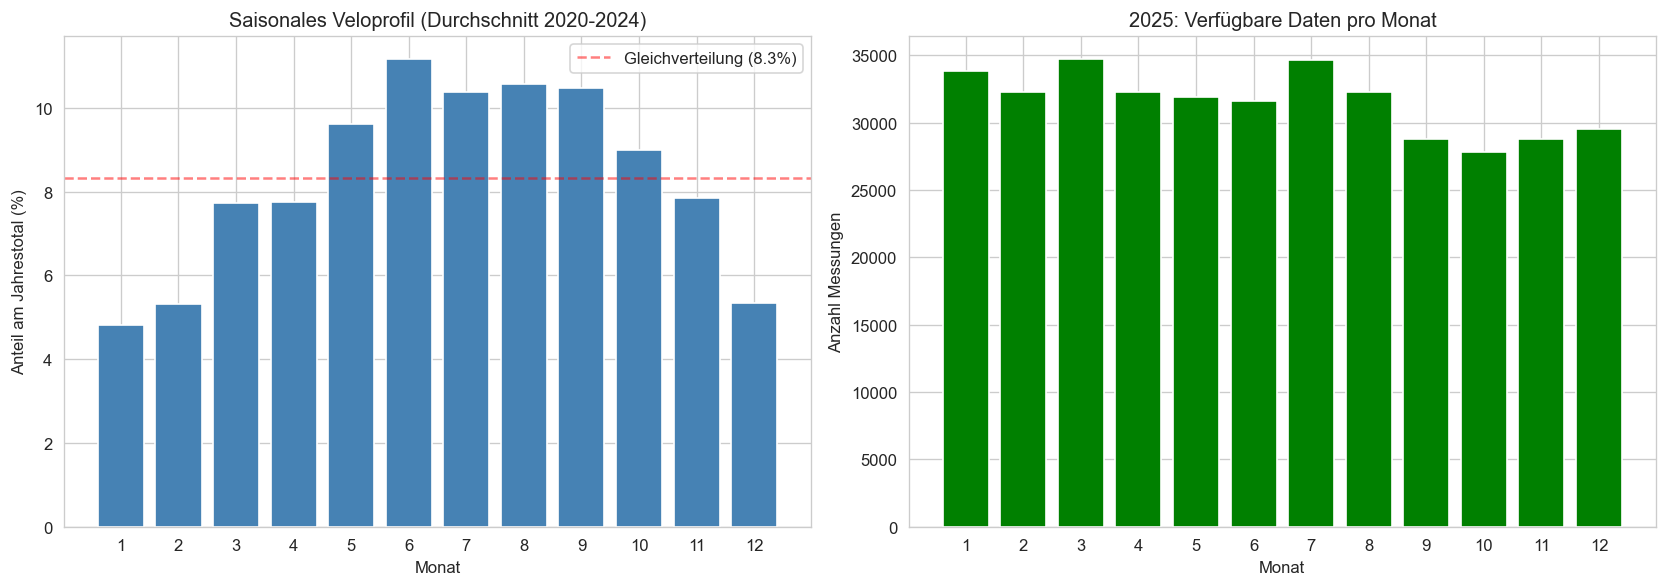

In [7]:
# Monatliche Totale über alle konsistenten Stationen  -  saisonales Profil
monthly = df_cons.groupby(["year", "month"])["velo_total"].sum().reset_index()

# Saisonprofil: Durchschnitt pro Monat über die vollständigen Jahre
full_years = [y for y in sorted(df_cons["year"].unique()) if y <= 2024]
monthly_profile = (
    monthly[monthly["year"].isin(full_years)]
    .groupby("month")["velo_total"]
    .mean()
)

# Normalisieren: jeder Monat als Anteil am Jahrestotal
monthly_share = monthly_profile / monthly_profile.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: Saisonprofil
axes[0].bar(monthly_share.index, monthly_share.values * 100, color="steelblue")
axes[0].set_xlabel("Monat")
axes[0].set_ylabel("Anteil am Jahrestotal (%)")
axes[0].set_title(f"Saisonales Veloprofil (Durchschnitt {full_years[0]}-{full_years[-1]})")
axes[0].set_xticks(range(1, 13))
axes[0].axhline(y=100/12, color="red", linestyle="--", alpha=0.5, label="Gleichverteilung (8.3%)")
axes[0].legend()

# Rechts: 2025 Abdeckung  -  welche Monate haben wir?
if 2025 in df_cons["year"].unique():
    m2025 = df_cons[df_cons["year"] == 2025].groupby("month")["velo_total"].count()
    coverage_2025 = pd.Series(0, index=range(1, 13))
    coverage_2025.update(m2025)
    colors = ["green" if v > 0 else "lightgray" for v in coverage_2025.values]
    axes[1].bar(coverage_2025.index, coverage_2025.values, color=colors)
    axes[1].set_xlabel("Monat")
    axes[1].set_ylabel("Anzahl Messungen")
    axes[1].set_title("2025: Verfügbare Daten pro Monat")
    axes[1].set_xticks(range(1, 13))
    
    # Berechne saisonale Verzerrung: Anteil der vorhandenen Monate am Jahresprofil
    covered_months = [m for m in range(1, 13) if coverage_2025[m] > 0]
    seasonal_share = monthly_share[covered_months].sum()
    print(f"2025 deckt Monate {covered_months} ab")
    print(f"Diese Monate machen {seasonal_share * 100:.1f}% des typischen Jahresverkehrs aus")
    print(f"Einfache Annualisierung würde um Faktor {1/seasonal_share:.2f} statt {12/len(covered_months):.2f} hochrechnen")
    
    if abs(seasonal_share - len(covered_months) / 12) > 0.05:
        print("⚠ Saisonale Verzerrung erkannt  -  2025 wird für Regression ausgeschlossen!")
        EXCLUDE_2025 = True
    else:
        print("Saisonale Verzerrung akzeptabel  -  2025 kann verwendet werden.")
        EXCLUDE_2025 = False
else:
    axes[1].text(0.5, 0.5, "Keine 2025-Daten", ha="center", va="center", transform=axes[1].transAxes)
    EXCLUDE_2025 = True
    print("Keine 2025-Daten vorhanden  -  Regression nur mit 2020-2024.")

plt.tight_layout()
plt.show()

---
## Schritt 7: Finale Jahrestotale für die Regression

Basierend auf dem Saisonalitäts-Check erstellen wir nun die endgültigen Jahrestotale pro Station, die in die Trendanalyse eingehen. Wir verwenden die annualisierten Werte für vollständige Jahre und schliessen stark verzerrte partielle Jahre aus.

In [8]:
# Finale Jahrestotale: nur verwendbare Jahre
if EXCLUDE_2025:
    yearly = yearly_raw[yearly_raw["year"] <= 2024].copy()
    print("2025 ausgeschlossen wegen saisonaler Verzerrung oder fehlender Daten.")
else:
    yearly = yearly_raw.copy()

# Nur Zeilen mit gültigen annualisierten Werten
yearly = yearly.dropna(subset=["velo_annual"])

# Verwendete Jahre
years_used = sorted(yearly["year"].unique())
print(f"Verwendete Jahre: {years_used}")
print(f"Stationen: {yearly['station_id'].nunique()}")
print(f"Station-Jahr-Kombinationen: {len(yearly)}")

# Pivot für Übersicht
final_pivot = yearly.pivot(index="station_id", columns="year", values="velo_annual")
print(f"\nFinale annualisierte Jahrestotale:")
print(final_pivot.round(0).to_string())

Verwendete Jahre: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Stationen: 12
Station-Jahr-Kombinationen: 67

Finale annualisierte Jahrestotale:
year             2020       2021       2022       2023       2024       2025
station_id                                                                  
732          368600.0   372428.0   427545.0   428687.0   439347.0   452989.0
1037         941219.0   931368.0  1017098.0   988442.0   945187.0   951444.0
2986         322611.0   264503.0   282372.0   274164.0   283663.0   324438.0
2989        1830274.0  1359449.0  1371181.0  1341493.0  1307374.0  1289192.0
2991         222373.0   226786.0   600950.0   558147.0   477828.0   369780.0
2993         551930.0   514828.0   604371.0   568950.0   565005.0   549772.0
2997         457319.0   382746.0   407434.0   393364.0   372850.0   421333.0
3003         216834.0   201762.0   230963.0   318302.0   365405.0   405792.0
3012              NaN   514151.0  

---
## Schritt 8: Year-over-Year (YoY) Wachstumsraten

Bevor wir die Regression durchführen, berechnen wir die jährlichen Wachstumsraten pro Station. Das gibt uns ein erstes Bild, welche Stationen wachsen und welche schrumpfen.

**Formel:** `YoY = (Total_t - Total_{t-1}) / Total_{t-1} × 100`

Positive Werte = Wachstum, negative = Rückgang.

In [9]:
# YoY Wachstumsraten pro Station
yearly_sorted = yearly.sort_values(["station_id", "year"])
yearly_sorted["yoy_pct"] = (
    yearly_sorted.groupby("station_id")["velo_annual"]
    .pct_change() * 100
)

# Pivot der YoY-Raten
yoy_pivot = yearly_sorted.pivot(index="station_id", columns="year", values="yoy_pct")
print("Year-over-Year Wachstumsraten (%):\n")
print(yoy_pivot.round(1).to_string())

# Durchschnittliche YoY-Rate pro Station
avg_yoy = yearly_sorted.groupby("station_id")["yoy_pct"].mean().sort_values(ascending=False)
print(f"\nDurchschnittliche jährliche Wachstumsrate pro Station:")
for sid, rate in avg_yoy.items():
    arrow = "▲" if rate > 0 else "▼"
    print(f"  Station {sid}: {arrow} {rate:+.1f}%/Jahr")

Year-over-Year Wachstumsraten (%):

year        2020  2021   2022  2023  2024  2025
station_id                                     
732          NaN   1.0   14.8   0.3   2.5   3.1
1037         NaN  -1.0    9.2  -2.8  -4.4   0.7
2986         NaN -18.0    6.8  -2.9   3.5  14.4
2989         NaN -25.7    0.9  -2.2  -2.5  -1.4
2991         NaN   2.0  165.0  -7.1 -14.4 -22.6
2993         NaN  -6.7   17.4  -5.9  -0.7  -2.7
2997         NaN -16.3    6.5  -3.5  -5.2  13.0
3003         NaN  -7.0   14.5  37.8  14.8  11.1
3012         NaN   NaN    4.5  -2.3  -1.8   3.4
4241         NaN   NaN    9.0  -9.8   3.5  -6.8
4242         NaN   NaN   12.9   1.0   8.0  -0.9
4249         NaN   NaN    NaN  -7.8   2.9  -8.7

Durchschnittliche jährliche Wachstumsrate pro Station:
  Station 2991: ▲ +24.6%/Jahr
  Station 3003: ▲ +14.2%/Jahr
  Station 4242: ▲ +5.3%/Jahr
  Station 732: ▲ +4.3%/Jahr
  Station 3012: ▲ +1.0%/Jahr
  Station 2986: ▲ +0.7%/Jahr
  Station 1037: ▲ +0.3%/Jahr
  Station 2993: ▲ +0.3%/Jahr
  S

---
## Schritt 9: Lineare Regression pro Station

Die Kernanalyse von FF2: Für jede Station fitten wir eine lineare Regression `velo_annual ~ year`. Die Steigung (slope) zeigt den absoluten Wachstumstrend in Velofahrten/Jahr.

**Warum lineare Regression?**
- Einfach interpretierbar: "Station X gewinnt Y Fahrten pro Jahr dazu"
- Robust gegenüber einzelnen Ausreisser-Jahren
- Direkt extrapolierbar
- R²-Wert zeigt, wie linear (= konsistent) der Trend ist

Wir berechnen pro Station:
- **Slope**: Absolute Veränderung pro Jahr
- **R²**: Güte des linearen Fits (0-1, höher = konsistenterer Trend)
- **p-value**: Statistische Signifikanz des Trends

In [10]:
def fit_station_trend(group):
    """Lineare Regression für eine Station über die Jahre."""
    x = group["year"].values
    y = group["velo_annual"].values
    
    # Mindestens 3 Datenpunkte für sinnvolle Regression
    if len(x) < 3:
        return pd.Series({
            "slope": np.nan, "intercept": np.nan,
            "r_squared": np.nan, "p_value": np.nan,
            "n_years": len(x), "first_year_total": y[0],
            "last_year_total": y[-1],
        })
    
    result = stats.linregress(x, y)
    return pd.Series({
        "slope": result.slope,
        "intercept": result.intercept,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "n_years": len(x),
        "first_year_total": y[0],
        "last_year_total": y[-1],
    })

# Regression pro Station
trends = yearly.sort_values("year").groupby("station_id").apply(fit_station_trend).reset_index()

# Relative Steigung: slope als % des Durchschnittsaufkommens
station_means = yearly.groupby("station_id")["velo_annual"].mean()
trends["mean_annual"] = trends["station_id"].map(station_means)
trends["slope_pct"] = (trends["slope"] / trends["mean_annual"] * 100)

# Sortieren nach stärkstem relativem Wachstum
trends = trends.sort_values("slope_pct", ascending=False)

print("Regressionsergebnisse pro Station (sortiert nach relativem Wachstum):\n")
display_cols = ["station_id", "slope", "slope_pct", "r_squared", "p_value", "n_years", "mean_annual"]
print(trends[display_cols].to_string(
    index=False,
    formatters={
        "slope": "{:+,.0f}".format,
        "slope_pct": "{:+.1f}%".format,
        "r_squared": "{:.3f}".format,
        "p_value": "{:.4f}".format,
        "mean_annual": "{:,.0f}".format,
    }
))

Regressionsergebnisse pro Station (sortiert nach relativem Wachstum):

 station_id   slope slope_pct r_squared p_value  n_years mean_annual
       3003 +43,516    +15.0%     0.907  0.0033      6.0     289,843
       2991 +41,353    +10.1%     0.224  0.3427      6.0     409,311
       4242 +17,570     +4.8%     0.857  0.0241      5.0     369,744
        732 +17,824     +4.3%     0.876  0.0060      6.0     414,933
       2986  +1,669     +0.6%     0.015  0.8166      6.0     291,958
       2993  +2,981     +0.5%     0.036  0.7176      6.0     559,143
       3012  +1,681     +0.3%     0.067  0.6740      5.0     525,163
       1037  +1,827     +0.2%     0.011  0.8460      6.0     962,460
       2997  -6,391     -1.6%     0.153  0.4431      6.0     405,841
       4241  -5,756     -1.7%     0.275  0.3644      5.0     333,089
       4249 -46,772     -4.0%     0.757  0.1301      4.0   1,162,289
       2989 -82,609     -5.8%     0.568  0.0836      6.0   1,416,494


---
## Schritt 10: CAGR (Compound Annual Growth Rate)

Neben der linearen Regression berechnen wir die CAGR  -  die zusammengesetzte jährliche Wachstumsrate. Diese misst das *durchschnittliche* jährliche Wachstum unter Berücksichtigung von Zinseszins-Effekten.

**Formel:** `CAGR = (Endwert / Anfangswert)^(1/n) - 1`

Die CAGR ist besonders nützlich für die Verdopplungsfrage: Bei konstantem Wachstum verdoppelt sich das Aufkommen in `ln(2) / ln(1 + CAGR)` Jahren.

In [11]:
# CAGR berechnen
n_periods = trends["n_years"] - 1  # Anzahl Übergänge zwischen Jahren

trends["cagr"] = np.where(
    (trends["first_year_total"] > 0) & (n_periods > 0),
    (trends["last_year_total"] / trends["first_year_total"]) ** (1 / n_periods) - 1,
    np.nan
)

# Verdopplungszeit: Jahre bis sich das Aufkommen verdoppelt
# Nur für positive CAGR sinnvoll
trends["doubling_years"] = np.where(
    trends["cagr"] > 0,
    np.log(2) / np.log(1 + trends["cagr"]),
    np.inf  # Kein Wachstum → verdoppelt sich nie
)

# Wird sich die Station innerhalb von 5 Jahren verdoppeln?
trends["doubles_in_5y"] = trends["doubling_years"] <= 5

print("CAGR und Verdopplungszeit:\n")
cagr_display = trends[["station_id", "cagr", "doubling_years", "doubles_in_5y", "first_year_total", "last_year_total"]].copy()
cagr_display = cagr_display.sort_values("cagr", ascending=False)

for _, row in cagr_display.iterrows():
    cagr_str = f"{row['cagr']*100:+.1f}%/Jahr" if pd.notnull(row['cagr']) else "N/A"
    doubl_str = f"{row['doubling_years']:.1f} Jahre" if row['doubling_years'] < 100 else "nie"
    flag = " ★ VERDOPPLUNG <5J" if row['doubles_in_5y'] else ""
    print(f"  Station {row['station_id']:>5}: CAGR {cagr_str:>12}, Verdopplung in {doubl_str:>12}{flag}")

n_doubling = trends["doubles_in_5y"].sum()
print(f"\n→ {n_doubling} Station(en) verdoppeln ihr Aufkommen voraussichtlich innerhalb von 5 Jahren.")

# Trend-Qualität (für spätere Hover-Tooltips und Filter)
def _classify_trend(row):
    if pd.isnull(row["p_value"]):
        return "insufficient_data"
    if row["p_value"] < 0.05 and row["r_squared"] >= 0.7:
        return "strong"
    if row["p_value"] < 0.10 or row["r_squared"] >= 0.5:
        return "moderate"
    return "weak"

trends["trend_quality"] = trends.apply(_classify_trend, axis=1)


CAGR und Verdopplungszeit:

  Station  3003: CAGR  +13.4%/Jahr, Verdopplung in    5.5 Jahre
  Station  2991: CAGR  +10.7%/Jahr, Verdopplung in    6.8 Jahre
  Station  4242: CAGR   +5.1%/Jahr, Verdopplung in   13.9 Jahre
  Station   732: CAGR   +4.2%/Jahr, Verdopplung in   16.8 Jahre
  Station  3012: CAGR   +0.9%/Jahr, Verdopplung in   75.9 Jahre
  Station  1037: CAGR   +0.2%/Jahr, Verdopplung in          nie
  Station  2986: CAGR   +0.1%/Jahr, Verdopplung in          nie
  Station  2993: CAGR   -0.1%/Jahr, Verdopplung in          nie
  Station  4241: CAGR   -1.3%/Jahr, Verdopplung in          nie
  Station  2997: CAGR   -1.6%/Jahr, Verdopplung in          nie
  Station  4249: CAGR   -4.7%/Jahr, Verdopplung in          nie
  Station  2989: CAGR   -6.8%/Jahr, Verdopplung in          nie

→ 0 Station(en) verdoppeln ihr Aufkommen voraussichtlich innerhalb von 5 Jahren.


---
## Schritt 11: Trendextrapolation visualisieren

Wir visualisieren die Trendlinien für alle Stationen  -  mit 5-Jahres-Projektion. Die Extrapolation zeigt, wo bei Fortschreibung der aktuellen Trends die Kapazitätsgrenzen als erstes erreicht werden.

**Wichtig:** Extrapolation ist keine Prognose! Lineare Fortschreibung ignoriert Sättigungseffekte, politische Änderungen und externe Schocks. Sie dient als Planungsinstrument ("Was passiert, wenn nichts getan wird?"), nicht als Vorhersage.

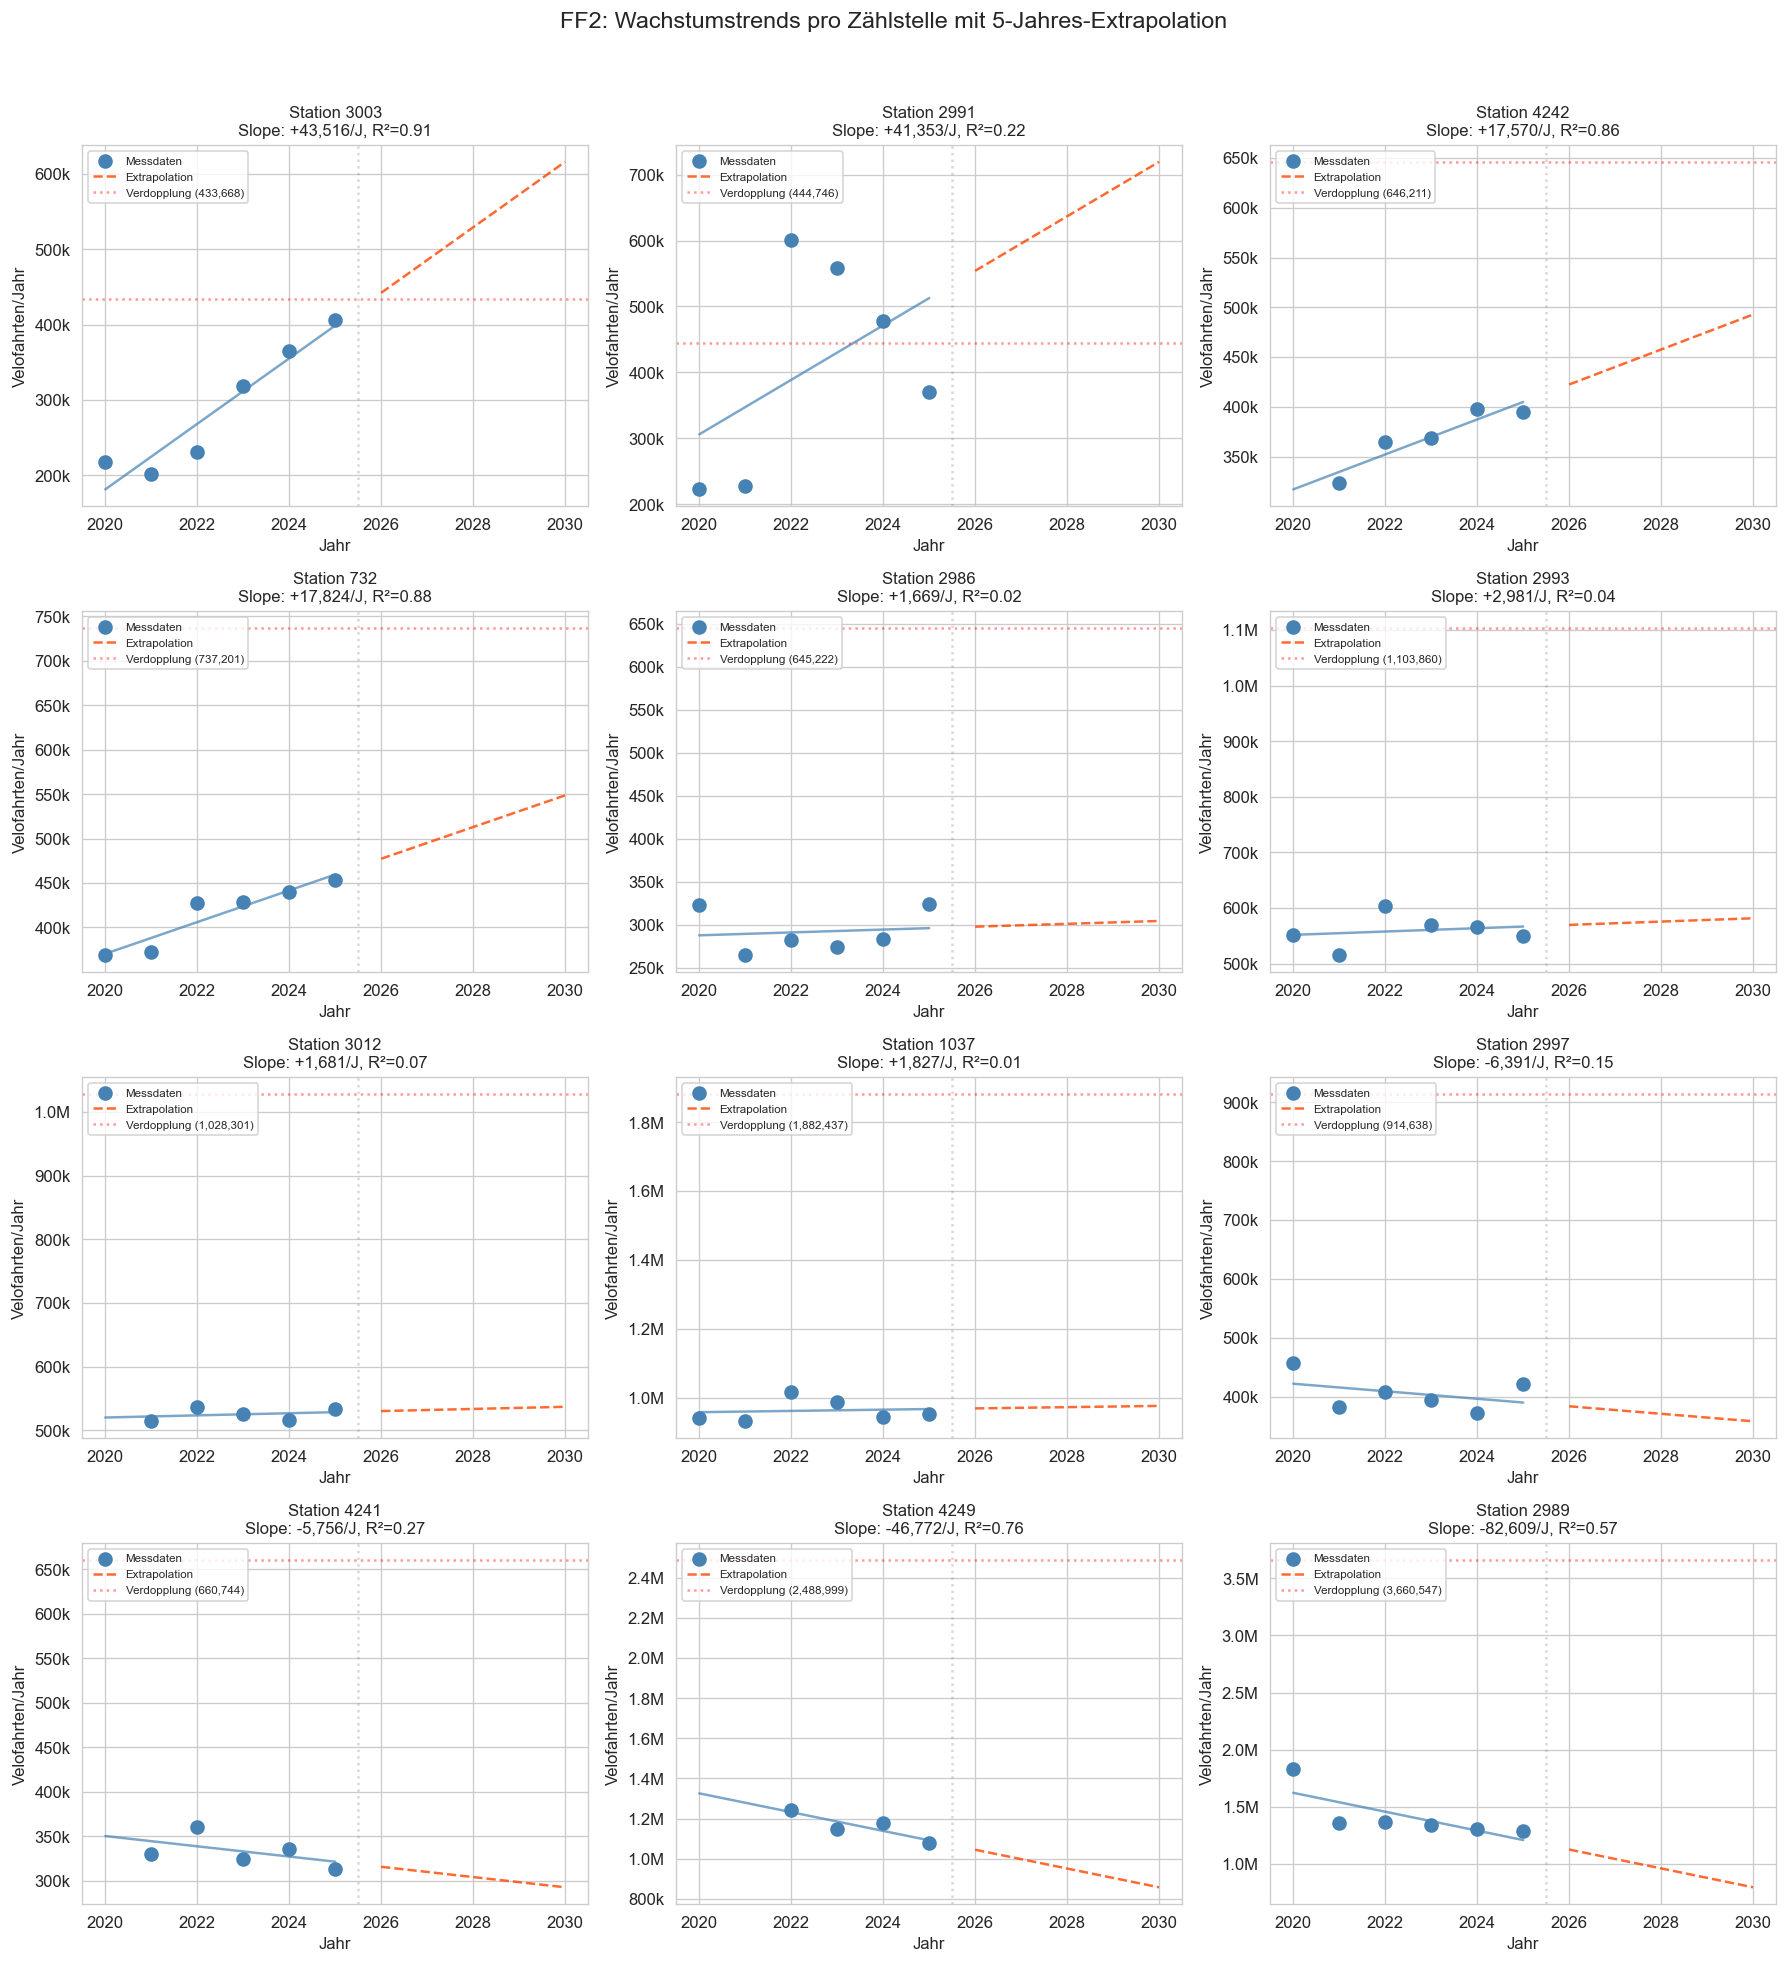

In [12]:
# Trendlinien mit Extrapolation
EXTRAPOLATION_YEARS = 5
last_data_year = max(years_used)
future_years = np.arange(last_data_year + 1, last_data_year + EXTRAPOLATION_YEARS + 1)
all_years_plot = np.arange(min(years_used), last_data_year + EXTRAPOLATION_YEARS + 1)

# Anzahl Stationen bestimmt das Grid-Layout
n_stations = len(trends)
n_cols = min(3, n_stations)
n_rows = int(np.ceil(n_stations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (_, row) in enumerate(trends.iterrows()):
    ax = axes_flat[i]
    sid = row["station_id"]
    
    # Tatsächliche Daten
    station_data = yearly[yearly["station_id"] == sid].sort_values("year")
    ax.scatter(station_data["year"], station_data["velo_annual"], 
               color="steelblue", zorder=5, s=60, label="Messdaten")
    
    if pd.notnull(row["slope"]):
        # Trendlinie (historisch)
        trend_y_hist = row["intercept"] + row["slope"] * np.array(years_used, dtype=float)
        ax.plot(years_used, trend_y_hist, color="steelblue", linestyle="-", alpha=0.7)
        
        # Extrapolation (Zukunft)
        trend_y_future = row["intercept"] + row["slope"] * future_years.astype(float)
        ax.plot(future_years, trend_y_future, color="orangered", linestyle="--", alpha=0.8, label="Extrapolation")
        
        # Verdopplungslinie
        double_val = row["first_year_total"] * 2
        ax.axhline(y=double_val, color="red", linestyle=":", alpha=0.4, label=f"Verdopplung ({double_val:,.0f})")
    
    # Trennlinie: historisch vs. Zukunft
    ax.axvline(x=last_data_year + 0.5, color="gray", linestyle=":", alpha=0.3)
    
    ax.set_title(f"Station {sid}\nSlope: {row['slope']:+,.0f}/J, R²={row['r_squared']:.2f}", fontsize=10)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Velofahrten/Jahr")
    ax.legend(fontsize=7, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"))

# Leere Subplots ausblenden
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("FF2: Wachstumstrends pro Zählstelle mit 5-Jahres-Extrapolation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Schritt 12: Wachstums-Ranking  -  Übersichtskarte

Ein Balkendiagramm mit dem Wachstums-Ranking aller Stationen. Wir zeigen sowohl den absoluten Trend (Slope) als auch den relativen Trend (CAGR), da beide unterschiedliche Perspektiven bieten:
- **Absoluter Trend (Slope):** Wo werden absolut die meisten zusätzlichen Fahrten generiert?
- **Relativer Trend (CAGR):** Wo wächst der Verkehr am stärksten *im Verhältnis zum bestehenden Aufkommen*?

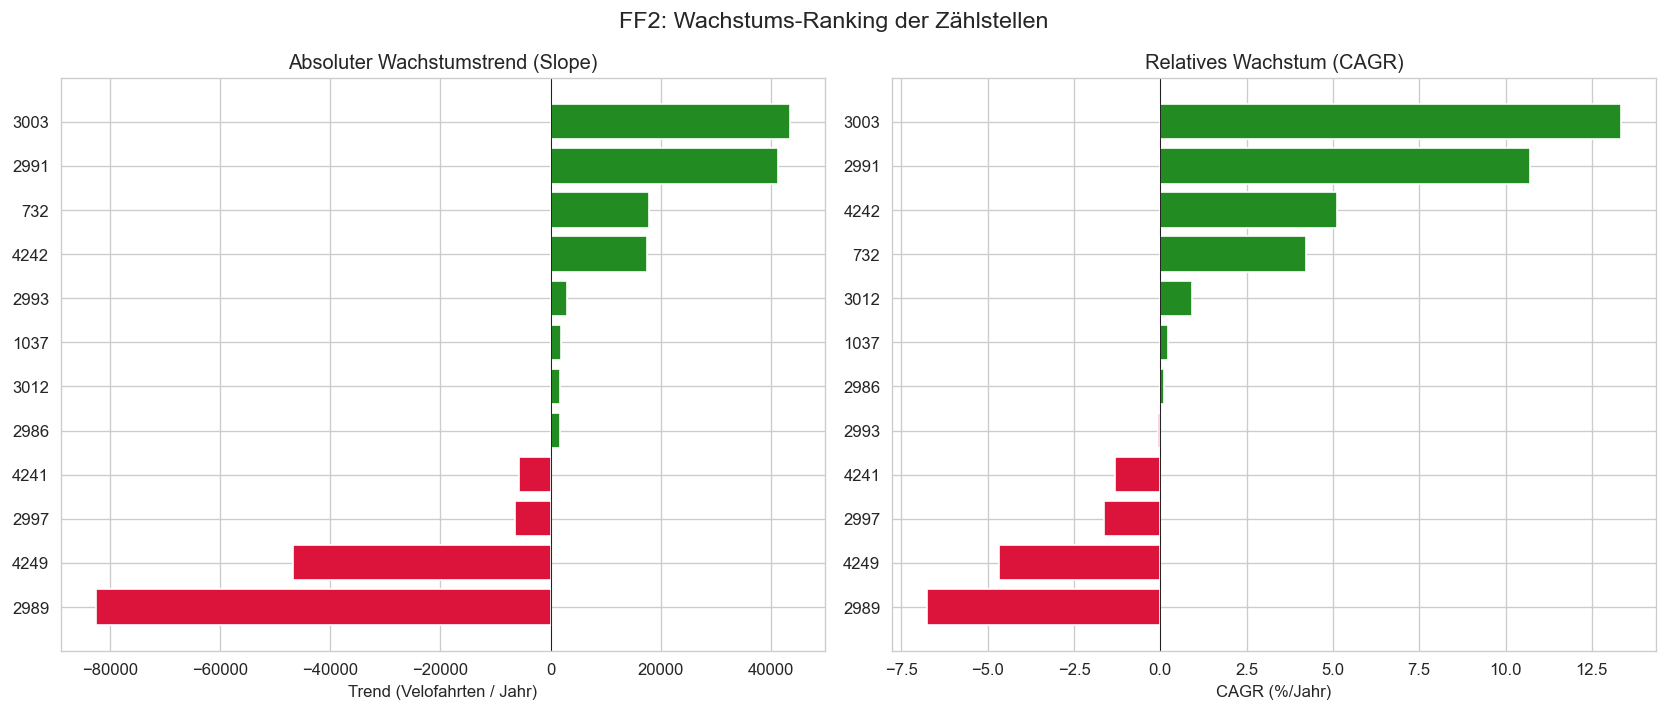

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, n_stations * 0.4)))

# Links: Absoluter Trend (Slope)
trends_abs = trends.dropna(subset=["slope"]).sort_values("slope")
colors_abs = ["forestgreen" if s > 0 else "crimson" for s in trends_abs["slope"]]
axes[0].barh(trends_abs["station_id"].astype(str), trends_abs["slope"], color=colors_abs)
axes[0].set_xlabel("Trend (Velofahrten / Jahr)")
axes[0].set_title("Absoluter Wachstumstrend (Slope)")
axes[0].axvline(x=0, color="black", linewidth=0.5)

# Rechts: Relativer Trend (CAGR)
trends_rel = trends.dropna(subset=["cagr"]).sort_values("cagr")
colors_rel = ["forestgreen" if c > 0 else "crimson" for c in trends_rel["cagr"]]
axes[1].barh(trends_rel["station_id"].astype(str), trends_rel["cagr"] * 100, color=colors_rel)
axes[1].set_xlabel("CAGR (%/Jahr)")
axes[1].set_title("Relatives Wachstum (CAGR)")
axes[1].axvline(x=0, color="black", linewidth=0.5)

fig.suptitle("FF2: Wachstums-Ranking der Zählstellen", fontsize=14)
plt.tight_layout()
plt.show()

---
## Schritt 13: Signifikanzfilter  -  Welche Trends sind statistisch belastbar?

Nicht jeder berechnete Trend ist statistisch signifikant. Ein R² von 0.1 bei 4 Datenpunkten hat wenig Aussagekraft. Wir klassifizieren die Trends:

- **Starker Trend:** p-value < 0.05 UND R² ≥ 0.7 → Konsistentes, signifikantes Wachstum
- **Moderater Trend:** p-value < 0.10 ODER R² ≥ 0.5 → Richtung erkennbar, aber nicht eindeutig
- **Schwacher/kein Trend:** Alles andere → Kein belastbarer Wachstumstrend

Für die Priorisierung (CPA Step 5) verwenden wir nur Stationen mit starkem oder moderatem Trend.

In [14]:
def classify_trend(row):
    if pd.isnull(row["p_value"]):
        return "insufficient_data"
    if row["p_value"] < 0.05 and row["r_squared"] >= 0.7:
        return "strong"
    if row["p_value"] < 0.10 or row["r_squared"] >= 0.5:
        return "moderate"
    return "weak"

trends["trend_quality"] = trends.apply(classify_trend, axis=1)

# Zusammenfassung
print("Trendqualität der Stationen:\n")
for quality in ["strong", "moderate", "weak", "insufficient_data"]:
    subset = trends[trends["trend_quality"] == quality]
    label = {
        "strong": "Stark (p<0.05, R²≥0.7)",
        "moderate": "Moderat (p<0.10 oder R²≥0.5)",
        "weak": "Schwach",
        "insufficient_data": "Zu wenig Daten",
    }[quality]
    stations = ", ".join(str(s) for s in subset["station_id"].values)
    print(f"  {label}: {len(subset)} Stationen")
    if len(subset) > 0:
        print(f"    → {stations}")

# Wachstums-Hotspots: starkes oder moderates Wachstum
hotspots = trends[
    (trends["trend_quality"].isin(["strong", "moderate"])) & 
    (trends["slope"] > 0)
].sort_values("slope_pct", ascending=False)

print(f"\n{'='*60}")
print(f"WACHSTUMS-HOTSPOTS (statistisch belastbar, positiver Trend):")
print(f"{'='*60}")
if len(hotspots) > 0:
    for _, row in hotspots.iterrows():
        print(f"  Station {row['station_id']}: {row['slope']:+,.0f} Fahrten/Jahr "
              f"({row['slope_pct']:+.1f}%), CAGR {row['cagr']*100:+.1f}%, "
              f"R²={row['r_squared']:.2f}, Verdopplung in {row['doubling_years']:.1f}J")
else:
    print("  Keine Stationen mit statistisch signifikantem Wachstumstrend gefunden.")

Trendqualität der Stationen:

  Stark (p<0.05, R²≥0.7): 3 Stationen
    → 3003, 4242, 732
  Moderat (p<0.10 oder R²≥0.5): 2 Stationen
    → 4249, 2989
  Schwach: 7 Stationen
    → 2991, 2986, 2993, 3012, 1037, 2997, 4241
  Zu wenig Daten: 0 Stationen

WACHSTUMS-HOTSPOTS (statistisch belastbar, positiver Trend):
  Station 3003: +43,516 Fahrten/Jahr (+15.0%), CAGR +13.4%, R²=0.91, Verdopplung in 5.5J
  Station 4242: +17,570 Fahrten/Jahr (+4.8%), CAGR +5.1%, R²=0.86, Verdopplung in 13.9J
  Station 732: +17,824 Fahrten/Jahr (+4.3%), CAGR +4.2%, R²=0.88, Verdopplung in 16.8J


---
## Schritt 14: CPA-Entscheidungsgrundlage (Step 5)

Basierend auf den Ergebnissen formulieren wir die Entscheidungsgrundlage gemäss dem CPA-Framework:

**Wenn Wachstum konzentriert (Ergebnis A):**
> Präventive Kapazitätserweiterung an den identifizierten Wachstums-Hotspots einplanen. Die Dringlichkeit ergibt sich aus der Verdopplungszeit.

**Wenn Wachstum gleichmässig (Ergebnis B):**
> Netzweite Standards anheben (z.B. Mindestbreiten, Signalisation). Einzelstandort-Priorisierung ist weniger sinnvoll.

In [15]:
# Konzentrations-Analyse: Ist das Wachstum auf wenige Stationen konzentriert?
growing = trends[trends["slope"] > 0].copy()
shrinking = trends[trends["slope"] < 0].copy()
flat = trends[trends["slope"].abs() < trends["slope"].abs().median() * 0.1]

print(f"Wachsend: {len(growing)} Stationen")
print(f"Schrumpfend: {len(shrinking)} Stationen")

if len(growing) > 0:
    # Gini-ähnliche Analyse: Wie ungleich ist das Wachstum verteilt?
    slopes_positive = growing["slope"].sort_values().values
    total_growth = slopes_positive.sum()
    cumulative = np.cumsum(slopes_positive) / total_growth
    
    # Top-3 Anteil am Gesamtwachstum
    top_n = min(3, len(growing))
    top_share = growing.nlargest(top_n, "slope")["slope"].sum() / total_growth * 100
    
    print(f"\nTop {top_n} Stationen machen {top_share:.0f}% des Gesamtwachstums aus.")
    
    if top_share > 60:
        print(f"\n→ ERGEBNIS A: Wachstum ist KONZENTRIERT.")
        print(f"  Empfehlung: Präventive Kapazitätserweiterung an diesen Korridoren.")
    else:
        print(f"\n→ ERGEBNIS B: Wachstum ist GLEICHMÄSSIG verteilt.")
        print(f"  Empfehlung: Netzweite Standards anheben.")

Wachsend: 8 Stationen
Schrumpfend: 4 Stationen

Top 3 Stationen machen 80% des Gesamtwachstums aus.

→ ERGEBNIS A: Wachstum ist KONZENTRIERT.
  Empfehlung: Präventive Kapazitätserweiterung an diesen Korridoren.


---
## Schritt 15: Wachstums-Hotspots auf der Zürich-Karte

Jede Zählstelle wird als konzentrische Kreisstruktur dargestellt &#8211; 
der Radius ist proportional zur Stärke des Wachstumstrends. 
Die Farbe zeigt die Richtung (grün = Wachstum, rot = Rückgang). 
Klick auf den Mittelpunkt-Marker zeigt die vollen Statistiken pro Station.


In [16]:
import folium
from pyproj import Transformer

# LV95 (Swiss) -> WGS84 (lat/lon)
transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

map_data = trends.merge(
    meta[["station_id", "easting", "northing"]],
    on="station_id",
    how="left",
)
map_data["lon"], map_data["lat"] = transformer.transform(
    map_data["easting"].values, map_data["northing"].values
)

# Karte zentriert auf Zürich
center_lat = map_data["lat"].mean()
center_lon = map_data["lon"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron")

# Radius-Skalierung: stärkster absoluter Trend bekommt MAX_RADIUS_M
max_abs_slope = map_data["slope"].abs().max()
BASE_RADIUS_M = 120
MAX_RADIUS_M  = 900

for _, row in map_data.iterrows():
    sid = int(row["station_id"])
    slope = row["slope"]
    cagr  = row["cagr"] * 100 if pd.notnull(row["cagr"]) else 0
    color = "#1a7f37" if slope > 0 else "#cf222e"   # green / red

    radius_m = BASE_RADIUS_M + (abs(slope) / max_abs_slope) * (MAX_RADIUS_M - BASE_RADIUS_M)

    # Radar-Effekt: 3 konzentrische Kreise mit abnehmender Deckkraft
    for mult, opa in [(1.0, 0.35), (1.6, 0.18), (2.3, 0.07)]:
        folium.Circle(
            location=[row["lat"], row["lon"]],
            radius=radius_m * mult,
            color=color, weight=0,
            fill=True, fill_color=color, fill_opacity=opa,
        ).add_to(m)

    # Zentrum-Marker mit Popup
    doubl = f"{row['doubling_years']:.1f}J" if row['doubling_years'] < 100 else "nie"
    popup_html = f"""
    <div style="font-family: Arial; width: 230px;">
        <h4 style="margin:0 0 8px 0; color:{color};">Station {sid}</h4>
        <table style="font-size: 13px; width: 100%;">
            <tr><td><b>Trend:</b></td><td>{slope:+,.0f} Fahrten/Jahr</td></tr>
            <tr><td><b>Relativ:</b></td><td>{row['slope_pct']:+.1f}%/Jahr</td></tr>
            <tr><td><b>CAGR:</b></td><td>{cagr:+.1f}%</td></tr>
            <tr><td><b>R²:</b></td><td>{row['r_squared']:.3f}</td></tr>
            <tr><td><b>Qualität:</b></td><td>{row['trend_quality']}</td></tr>
            <tr><td><b>Verdopplung:</b></td><td>{doubl}</td></tr>
            <tr><td><b>Ø Fahrten/J:</b></td><td>{row['mean_annual']:,.0f}</td></tr>
        </table>
    </div>
    """
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color, weight=2,
        fill=True, fill_color="white", fill_opacity=1,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=f"Station {sid}: {slope:+,.0f}/Jahr ({cagr:+.1f}%)",
    ).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 14px 16px; border-radius: 8px; border: 1px solid #ddd;
     box-shadow: 0 2px 8px rgba(0,0,0,0.15);
     font-family: Arial; font-size: 13px;">
    <b style="font-size: 14px;">Wachstumstrend</b><br><br>
    <span style="color:#1a7f37; font-size:18px;">&#9679;</span> Wachsende Station<br>
    <span style="color:#cf222e; font-size:18px;">&#9679;</span> Schrumpfende Station<br>
    <i style="color:#666;">Kreisgr&ouml;sse &#8733; St&auml;rke des Trends</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save standalone HTML so VSCode can render via IFrame (bypasses the
# notebook-trust issue that blocks folium's srcdoc iframe)
m.save("ff2_zuerich_map.html")
print("Karte gespeichert: ff2_zuerich_map.html (öffnet auch direkt im Browser)")

from IPython.display import IFrame
IFrame("ff2_zuerich_map.html", width="100%", height=600)


Karte gespeichert: ff2_zuerich_map.html (öffnet auch direkt im Browser)


---
## Schritt 16: Export  -  FF2-Ergebnisse speichern

Wir speichern die Trendanalyse als CSV, damit sie in Notebook 04+ für die Synthese (Prioritätsscore über alle FFs) weiterverwendet werden kann.

In [17]:
import os

# Export-Verzeichnis
os.makedirs("data/clean", exist_ok=True)

# Trend-Ergebnisse exportieren
export_cols = [
    "station_id", "slope", "slope_pct", "intercept", "r_squared", "p_value",
    "cagr", "doubling_years", "doubles_in_5y", "trend_quality",
    "mean_annual", "first_year_total", "last_year_total", "n_years",
]
trends[export_cols].to_csv("data/clean/ff2_growth_trends.csv", index=False)

# Jahrestotale exportieren (für spätere Visualisierungen)
yearly[["station_id", "year", "velo_total_sum", "velo_annual", "coverage_pct"]].to_csv(
    "data/clean/ff2_yearly_totals.csv", index=False
)

print("Exportiert:")
print(f"  data/clean/ff2_growth_trends.csv  ({len(trends)} Stationen)")
print(f"  data/clean/ff2_yearly_totals.csv  ({len(yearly)} Station-Jahre)")
print(f"\nSpalten in ff2_growth_trends.csv:")
for col in export_cols:
    print(f"  - {col}")

Exportiert:
  data/clean/ff2_growth_trends.csv  (12 Stationen)
  data/clean/ff2_yearly_totals.csv  (67 Station-Jahre)

Spalten in ff2_growth_trends.csv:
  - station_id
  - slope
  - slope_pct
  - intercept
  - r_squared
  - p_value
  - cagr
  - doubling_years
  - doubles_in_5y
  - trend_quality
  - mean_annual
  - first_year_total
  - last_year_total
  - n_years


---
## Zusammenfassung der Datenaufbereitungs-Schritte

| Schritt | Was | Warum | Auswirkung |
|---------|-----|-------|------------|
| 1. Daten laden | Parquet + Metadaten aus NB02 | Bereinigte Ausgangsdaten verwenden |  -  |
| 2. Konsistente Stationen | Filter auf `is_consistent == True` | Nur Stationen mit Daten über alle Jahre → fairer Vergleich | Reduziert Stationsanzahl |
| 3. Sensor-Ausfälle | Entferne `is_sensor_failure` / NaN | Keine falschen Nullen in Jahressummen | Entfernt fehlerhafte Messungen |
| 4. Abdeckung prüfen | Coverage % pro Station-Jahr | Transparenz über Datenqualität | Identifiziert lückenhafte Jahre |
| 5. Annualisierung | `raw_sum / coverage` für partielle Jahre | 2025 wäre sonst nicht vergleichbar | Ermöglicht Vergleich trotz Lücken |
| 6. Saisonalitäts-Check | Verzerrung durch Wintermonate prüfen | Einfache Annualisierung unterschätzt bei Winterdaten | Entscheidung: 2025 ein-/ausschliessen |
| 7. Finale Totale | Zusammenführung der bereinigten Werte | Saubere Basis für Regression |  -  |
| 8. YoY-Raten | Jährliche Wachstumsraten | Erstes Trendbild |  -  |
| 9. Lineare Regression | Slope, R², p-value pro Station | Statistisch fundierter Trend | Kern der Analyse |
| 10. CAGR | Zusammengesetztes Wachstum | Verdopplungszeit berechnen | Beantwortet die FF2-Frage |
| 11. Visualisierung | Trendlinien + Extrapolation | Kommunikation der Ergebnisse |  -  |
| 12. Ranking | Absolute + relative Balkendiagramme | Priorisierung der Stationen |  -  |
| 13. Signifikanzfilter | Klassifikation stark/moderat/schwach | Nur belastbare Trends für Entscheidungen | Filtert Rauschen |
| 14. CPA-Entscheid | Konzentrations-Analyse | Ergebnis A vs. B bestimmen | Management-Empfehlung |
| 15. Export | CSVs für Synthese | Weiterverwendung in NB04+ |  -  |